In [11]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder.master("local[10]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

df = spark.read.parquet("/home/h487/data/parquet/run1083_srppac_koji.parquet")
df.show(5)
#df=df.filter("charge1_x > 0 AND charge1_y > 0 AND ABS(id0_x - id1_x) = 1 AND ABS(id0_y - id1_y) = 1")
#df.show(5)

+---------+--------------------+--------------------+--------------------+------+-------------------+------------------+-----------------+-----------------+-----+-----+-----+--------------------+--------------------+--------------------+--------------------+------+-------------------+------------------+-----------------+------------------+-----+-----+-----+--------------------+-------+
|hbfNumber|                id_x|            timing_x|            charge_x|size_x|          timing0_x|         charge0_x|        charge1_x|        charge2_x|id0_x|id1_x|id2_x|              q0q1_x|                id_y|            timing_y|            charge_y|size_y|          timing0_y|         charge0_y|        charge1_y|         charge2_y|id0_y|id1_y|id2_y|              q0q1_y|runname|
+---------+--------------------+--------------------+--------------------+------+-------------------+------------------+-----------------+-----------------+-----+-----+-----+--------------------+--------------------+------

Statistics:
[[2.0000e+00 8.0000e+00 0.0000e+00]
 [4.0000e+00 3.5473e+04 1.1000e+01]
 [0.0000e+00 0.0000e+00 0.0000e+00]]
Statistics:
[[1.0000e+00 9.0000e+00 0.0000e+00]
 [1.0000e+00 3.5401e+04 1.3000e+01]
 [0.0000e+00 0.0000e+00 0.0000e+00]]


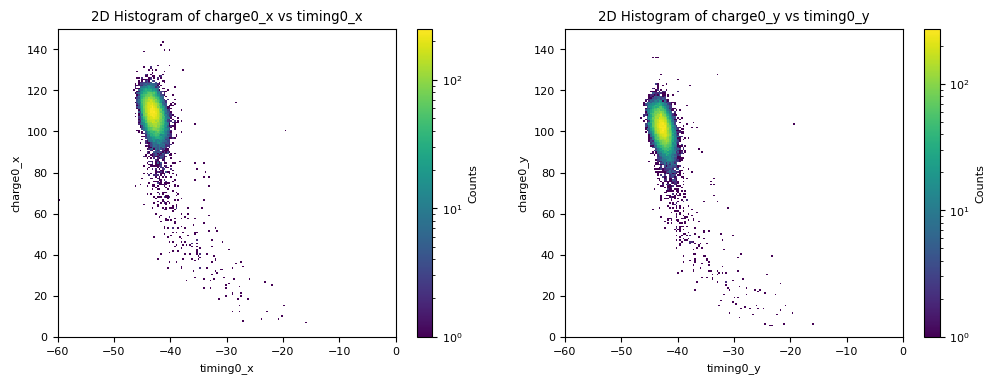

In [12]:
from hist.sparkHist2d import Hist2DArrays
from hist.sparkHist2d import Hist2D
from hist.sparkHist1d import Hist1D
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

plt.figure(0, figsize=(12,4))
plt.rcParams["font.size"] = 8
plt.subplot2grid((1,2),(0,0))
h = Hist2D(df, ["timing0_x","charge0_x"], [200,200], [[-60, 0], [0, 150]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((1,2),(0,1))
h = Hist2D(df, ["timing0_y","charge0_y"], [200,200], [[-60, 0], [0, 150]], norm=LogNorm(), interpolation='none')
plt.show()  

In [ ]:
plt.figure(0, figsize=(12,4))
plt.rcParams["font.size"] = 8
plt.subplot2grid((1,2),(0,0))
h = Hist1D(df, "size_x", 33, [-0.5, 31.5])
plt.yscale('log')
plt.subplot2grid((1,2),(0,1))
h = Hist1D(df, "size_y", 33, [-0.5, 31.5])
plt.yscale('log')
plt.show()

In [ ]:
plt.figure(0, figsize=(12,4))
plt.rcParams["font.size"] = 8
plt.subplot2grid((1,2),(0,0))
h = Hist2D(df.filter("size_x<9"), ["timing0_x","charge0_x"], [200,200], [[-50, 0], [0, 100]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((1,2),(0,1))
h = Hist2D(df.filter("size_y<9"), ["timing0_y","charge0_y"], [200,200], [[-50, 0], [0, 100]], norm=LogNorm(), interpolation='none')
plt.show() 

In [ ]:
df_f = df.filter("size_x<7").filter("size_y<7")
plt.figure(0, figsize=(12,6))
plt.rcParams["font.size"] = 6
plt.subplot2grid((2,3),(0,0))
h = Hist2D(df_f, ["id0_x","charge0_x"], [33,200], [[-0.5, 31.5], [0, 100]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,3),(0,1))
h = Hist2D(df_f, ["id1_x","charge1_x"], [33,200], [[-0.5, 31.5], [0, 100]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,3),(0,2))
h = Hist2D(df_f, ["id2_x","charge2_x"], [33,200], [[-0.5, 31.5], [0, 100]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,3),(1,0))
h = Hist2D(df_f, ["id0_y","charge0_y"], [33,200], [[-0.5, 31.5], [0, 100]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,3),(1,1))
h = Hist2D(df_f, ["id1_y","charge1_y"], [33,200], [[-0.5, 31.5], [0, 100]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,3),(1,2))
h = Hist2D(df_f, ["id2_y","charge2_y"], [33,200], [[-0.5, 31.5], [0, 100]], norm=LogNorm(), interpolation='none')
plt.show() 

XQ0count = df.filter("charge0_x>0").count()
XQ2count = df.filter("charge2_x>0").count()
Q2efficiency = XQ2count / XQ0count
print(f"X Q2 efficiency: {Q2efficiency:.4f}")

YQ0count = df.filter("charge0_y>0").count()
YQ2count = df.filter("charge2_y>0").count()
Q2efficiency = YQ2count / YQ0count
print(f"Y Q2 efficiency: {Q2efficiency:.4f}")



In [ ]:
h = Hist2D(df_f, ["id0_x","id0_y"], [33,33], [[-0.5, 31.5], [-0.5,31.5]], norm=LogNorm(), interpolation='none')
plt.show()
h = Hist2D(df_f, ["id1_x","id1_y"], [33,33], [[-0.5, 31.5], [-0.5,31.5]], norm=LogNorm(), interpolation='none')